# Converting solutions into climate impacts
Run Drawdown Explorer solutions through a reduced-complexity climate model (FaIR) to convert pollutant avoided into millidegrees of warming.

In [1]:
import os
from fair import FAIR
from fair.io import read_properties
from fair.interface import initialise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/katemarvel/miniforge3/envs/drawdown/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define times
We start in 1750 to give the model some time to spin up and run until the end of the 21st century.

In [2]:
fair_start_time = 1750
fair_end_time = 2100
timepoints = np.arange(fair_start_time,fair_end_time+1,1)

## Specify the baseline scenario
When projecting future counterfactuals, we need to specify the no-action scenario.  There are a couple ways we can do this:
* CMIP7 "medium" scenario (essentially a continuation of current policies). The assumptions for the adoption of any solution are unclear.  Methane and air pollution decline quickly, CO2 emissions flatline.
* Constant 2024 emissions.  This doesn't take into account projected technological or demographic changes, but is simple.
* Constant 2020 emissions with a continuation of current trends in air pollution legislation.  Could answer the question "can emergency brakes mitigate near term warming from aerosol reductions"?
  
**Default: constant emissions**

In [3]:
baseline_scenario="constant"

### Helper functions
There are currently 3 choices for time series: 
* Step function: solution is fully implemented immediately
* S curve: solution ramps up quickly and then saturates
* Linear ramp: solution is implemented at a constant rate over time.

In [4]:
def step_function(timepoints, t_start,L):
    """
    Step function for technology adoption.

    Parameters:
        timepoints:   Array of year timepoints.
        t_start:      Year adoption begins (curve is 0 before this).
        L:            Saturation level (maximum adoption)

    """
    return np.where(timepoints >= t_start, L, 0.0)

In [5]:
def S_curve(timepoints, t_start, L, k, t_mid_offset=None):
    """
    Logistic S-curve for technology adoption.

    Parameters:
        timepoints:   Array of year timepoints.
        t_start:      Year adoption begins (curve is 0 before this).
        L:            Saturation level (maximum adoption).
        k:            Growth rate / steepness. 
                        ~0.1 = slow, ~0.5 = moderate, ~1.0+ = fast S-curve.
        t_mid_offset: Years after t_start at which adoption is at 50% of L.
                        Defaults to 1/4 of the remaining time window.
    """
    t_end = timepoints[-1]
    if t_mid_offset is None:
        t_mid_offset = (t_end - t_start) / 4
    
    t_mid = t_start + t_mid_offset  # inflection point in absolute years

    raw = L / (1 + np.exp(-k * (timepoints - t_mid)))
    offset = L / (1 + np.exp(-k * (t_start - t_mid)))
    scale = L / (1 + np.exp(-k * (t_end - t_mid)))  - offset
    scaled = (raw - offset) / scale * L

    return np.where(timepoints < t_start, 0.0, np.clip(scaled, 0.0, L))

In [6]:
def linear_ramp(timepoints, t_start, L):
    """
    Linear ramp-up for technology adoption.

    Parameters:
        timepoints:   Array of year timepoints.
        t_start:      Year adoption begins (curve is 0 before this).
        L:            Saturation level (maximum adoption)
    """
    t_end =timepoints[-1]
    slope = L / (t_end - t_start)
    return np.where(timepoints < t_start, 0.0, slope * (timepoints - t_start))


### Example: S curve parameters

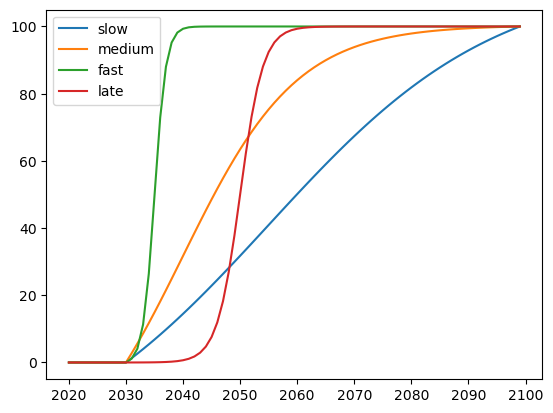

In [7]:
years = np.arange(2020, 2100)

slow   = S_curve(years, t_start=2030, L=100, k=0.05, t_mid_offset=25)  # near-linear
medium = S_curve(years, t_start=2030, L=100, k=0.1, t_mid_offset=10)  # classic S
fast   = S_curve(years, t_start=2030, L=100, k=1.0, t_mid_offset=5)   # rapid early jump
late   = S_curve(years, t_start=2030, L=100, k=0.5, t_mid_offset=20)  # slow to start, then catches up
plt.plot(years,slow,label="slow")
plt.plot(years,medium,label="medium")
plt.plot(years,fast,label="fast")
plt.plot(years,late,label="late")
plt.legend()


In [8]:
def drawdown_model(baseline_scenario, perturbation_dicts, df_configs=None,
                   start=1750, end=2101, lite=False, n_lite=10, emissions_year = 2024, random_seed=42):
    """
    Build and run a FaIR model instance

    Parameters:
        baseline_scenario: what emissions would do without action
        perturbation_dicts: dictionary of form d[scenario][specie]=timeseries of avoided emissions
        df_configs: parameters for the box model parameters 
        (ocean heat uptake, feedbacks, etc.)
        defaults to '../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv'
        start: start date (keep at 1750 for spinup)
        end: end date of simulation
        lite: run a configuration in reduced parameter space (saves memory)
        n_lite: the number of parameter values to use in lite mode
        emissions_year: when using a constant baseline, the year in which to freeze emissions
    """
    
    all_scenarios = [baseline_scenario] + list(perturbation_dicts.keys())
    
    if df_configs is None:
        df_configs = pd.read_csv(
            '../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv', 
            index_col=0
        )
    # ---lite mode: just pick n_lite configurations ---
    if lite:
        df_configs = df_configs.sample(n=n_lite, random_state=random_seed)
    
    species, properties = read_properties(
        '../data/fair-parameters/species_configs_properties_1.4.1.csv'
    )
    # --- temporary instance just to load the CSV ---
    f_tmp = FAIR()
    f_tmp.define_time(start, end, 1)
    if baseline_scenario != "constant":
        f_tmp.define_scenarios([baseline_scenario])
    else:
        f_tmp.define_scenarios(["high-extension"])
    f_tmp.define_species(species, properties)
    f_tmp.define_configs(df_configs.index)
    f_tmp.allocate()
    f_tmp.fill_from_csv(
        emissions_file='../data/emissions/extensions_1750-2500.csv',
        forcing_file='../data/forcing/volcanic_solar.csv',
    )

    if baseline_scenario != "constant":
        baseline_emissions = f_tmp.emissions.sel(scenario=baseline_scenario).copy()
        baseline_forcing = f_tmp.forcing.sel(scenario=baseline_scenario).copy()
    else:
        high_emissions = f_tmp.emissions.sel(scenario="high-extension").copy()
        high_forcing = f_tmp.forcing.sel(scenario="high-extension").copy()
        #### DEFINE CONSTANT EMISSIONS #####
        emissions_const=high_emissions.sel(timepoints=emissions_year,method="nearest")
        
        #step = step_function(timepoints, emissions_year)[:, np.newaxis, np.newaxis]
        step = np.where(timepoints<emissions_year,0.0,1.0)[:, np.newaxis, np.newaxis]
        baseline_emissions = (                                                        
          high_emissions.values * (1 - step) +       # ramps to 0 at 2024
          emissions_const.values[np.newaxis, :, :] * step  # ramps on at 2024        
        )
        
        timebounds = np.arange(fair_start_time, fair_end_time + 2, 1)  # 1750–2101,   
                                                                                                                                                      
        forcing_const = high_forcing.sel(timebounds=emissions_year, method="nearest")                                                                
                                                                                    
        step_bounds = np.where(timebounds<emissions_year,0.0,1.0 )[:, np.newaxis, np.newaxis] 
                                                                                    
        baseline_forcing = (
          high_forcing.values * (1 - step_bounds) +
          forcing_const.values[np.newaxis, :, :] * step_bounds
        )        

    del f_tmp

    # --- real instance with all scenarios ---
    f = FAIR()
    f.define_time(start, end, 1)
    f.define_scenarios(all_scenarios)
    f.define_species(species, properties)
    f.ch4_method = 'Thornhill2021'
    f.define_configs(df_configs.index)
    f.allocate()
    f.fill_species_configs(
        '../data/fair-parameters/species_configs_properties_1.4.1.csv'
    )
    f.override_defaults(
        '../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv'
    )

    for s in all_scenarios:
        f.emissions.loc[dict(scenario=s)] = baseline_emissions
        f.forcing.loc[dict(scenario=s)] = baseline_forcing

    for s, perturbation in perturbation_dicts.items():
        for specie, delta in perturbation.items():
            f.emissions.loc[dict(scenario=s, specie=specie)] += delta[:, np.newaxis]

    initialise(f.concentration, f.species_configs["baseline_concentration"])
    initialise(f.forcing, 0)
    initialise(f.temperature, 0)
    initialise(f.cumulative_emissions, 0)
    initialise(f.airborne_emissions, 0)
    initialise(f.ocean_heat_content_change, 0)

    f.run()
    return f

# Specifying the impacts of solutions
Solutions are coded as a dictionary of dictionaries, with each key as
<code>
scenario name: {specie_1: time series of emissions avoided,
                specie_2: time series of emissions avoided, ...
                specie_n: time series of emissions avoided}
</code>

## Interface with the solutions explorer
1. Download the service_account.json file in the team Drive: https://drive.google.com/drive/folders/1LLlGB6rMVrfTps2TCDwxMb9u4jtbyMiG
2. Navigate to the spreadsheet you want to work with in the google drive
3. Click "share"
4. Share with explorer-sheet-access@drawdown-solutions-translator.iam.gserviceaccount.com
5. Assign shname = name of the spreadsheet you want to work with
   
**DO NOT SHARE THE SERVICE ACCOUNT OUTSIDE PD**

In [9]:
solution_name = "Improve Diets"

In [10]:
import gspread

gc = gspread.service_account()

#gc.list_spreadsheet_files()[0]["name"]


shname = f'Drawdown Explorer {solution_name} Assessment Spreadsheet'

sh=gc.open(shname)

In [11]:
gwp=sh.worksheet('conversions: global warming potential')

current_effectiveness=sh.worksheet('2. current state effectiveness')
adoption=sh.worksheet('3. adoption')

In [12]:
ch4_gwp_20=float(gwp.acell("C3").value)
# instead of doing this use a dictionary of GWPs for all solutions
# tons of co2eq (20 year) per adoption unit
#this will move around
ch4_co2eq=float(current_effectiveness.acell("B7").value)
ch4_Tg=1.e-6*ch4_co2eq/ch4_gwp_20
co2_Gt=float(current_effectiveness.acell("B6").value)/1.e9

In [13]:
achievable_high=float(adoption.acell("V40").value)
achievable_low=float(adoption.acell("V31").value)

ch4_high=ch4_Tg*achievable_high
ch4_low=ch4_Tg*achievable_low

co2_high=co2_Gt*achievable_high
co2_low=co2_Gt*achievable_low

In [14]:

def plot_T_diff(f,baseline_scenario="constant"):
    baseline_T=f.temperature.sel(layer=0,\
                    scenario=baseline_scenario,\
                   timebounds=slice(2020,2100))
    for scenario in f.scenarios:
        if scenario != baseline_scenario:
            scen_T=f.temperature.sel(layer=0,\
                    scenario=scenario,\
                   timebounds=slice(2020,2100))
            deltaT=scen_T-baseline_T
            tax=deltaT.timebounds.values
            median = deltaT.median(dim="config")
            lo = deltaT.quantile(0.25, dim="config")
            hi = deltaT.quantile(0.75, dim="config")
        
            plt.plot(tax, median, label=scenario)
            plt.fill_between(tax, lo, hi, alpha=0.2)
    plt.legend()
    plt.xlabel("Year")
    plt.ylabel("Warming avoided (°C)")

In [23]:
implementation_year=2026
perturbation_dicts={
    f"{solution_name} (slow implementation)": {"CH4":-1*S_curve(timepoints,implementation_year,ch4_high,k=0.1),\
                 'CO2 AFOLU': -1*S_curve(timepoints,implementation_year,co2_high,k=0.1)},\
    f"{solution_name} (immediate implementation)":{"CH4":step_function(timepoints, implementation_year,-ch4_high),\
                 'CO2 AFOLU': step_function(timepoints, implementation_year,-co2_high)},\
}

In [25]:
f=drawdown_model("constant",perturbation_dicts,lite=True,n_lite=5)

Running 15 projections in parallel: 100%|█| 351/351 [00:00<00:00, 2583.13timeste


### Emissions scenarios
All scenarios have the same historical CH4 and CO2 emissions.

Text(0, 0.5, 'Tg')

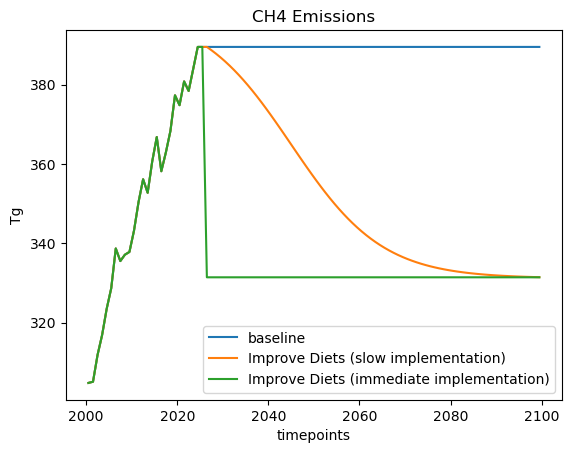

In [26]:
for scenario in f.scenarios:
    if scenario != "constant":
        labscenario=scenario
    else:
        labscenario="baseline"
    if scenario!="CO2 1Gt":
        f.emissions.sel(specie="CH4",\
                        scenario=scenario,\
                       timepoints=slice(2000,2100)).mean(dim="config").plot(label=labscenario)
plt.legend()
plt.title("CH4 Emissions")
plt.ylabel("Tg")

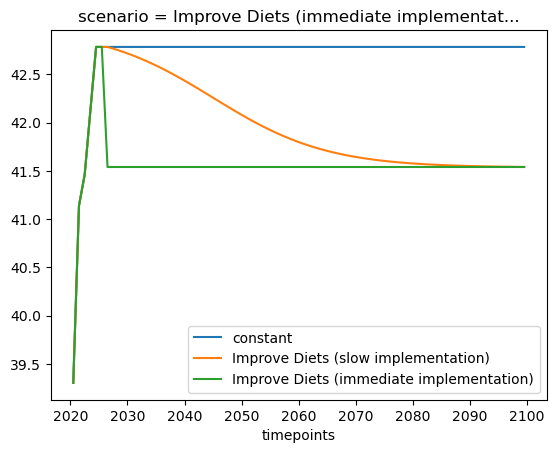

In [27]:
for scenario in f.scenarios:
    #if scenario in ["CO2 1Gt","constant"]:
    f.emissions.sel(specie="CO2",\
                    scenario=scenario,\
                   timepoints=slice(2020,2100)).mean(dim="config").plot(label=scenario)
plt.legend()

### Temperature difference
Both solutions reduce global warming, but the fast solution reduces it faster and more.

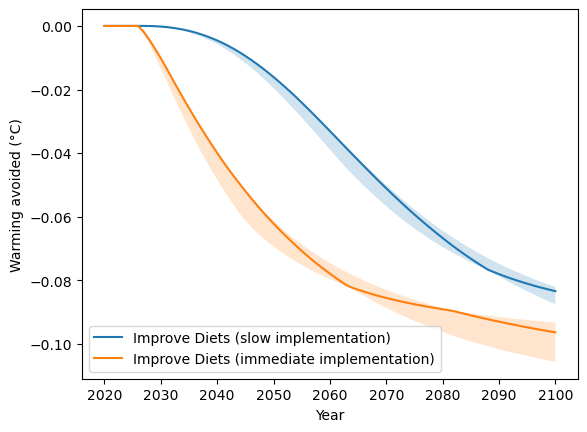

In [30]:
plot_T_diff(f,"constant")
plt.savefig("../plots/Drawdown/improve_diets.png")

In [22]:
# Delete the model for memory purposes
del f

# Emergency brakes
Another example to illustrate the differences between pollutants.  Compare a CO2 reduction scenario in which emissions are reduced by 1 Gt CO2 every year with an emergency brake CH4 mitigation scenario in which 14 tons .  

In [47]:
emergency_brake_dicts = {
    "Steady CO2 reduction": {"CO2 FFI": step_function(timepoints, 2030,-1.0)},
    "Emergency brake":     {"CH4":    step_function(timepoints, 2030,-14.)},
    "Delayed methane mitigation":     {"CH4": step_function(timepoints, 2070,-14.)},
    "Emergency brake + steady CO2 reduction":  {"CH4":    step_function(timepoints, 2030,-14.),
                                                "CO2 FFI":  step_function(timepoints, 2030,-1)}
}

In [48]:
emergency_f=drawdown_model("constant",emergency_brake_dicts,lite=True)

Running 50 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

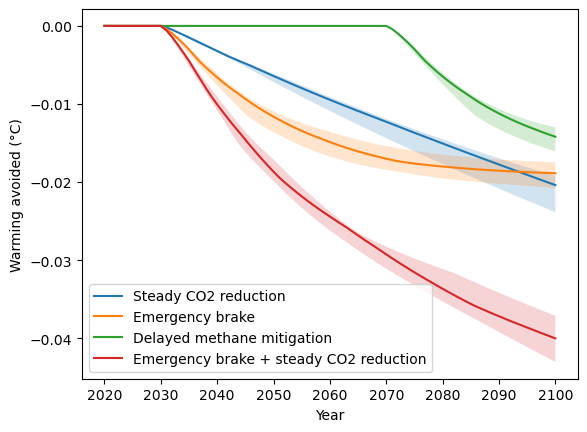

In [49]:
plot_T_diff(emergency_f,baseline_scenario="constant")

# Aerosols
Clean air legislation has successfully reduced global aerosol emissions and the aerosol burden, which has now shifted to East and South Asia, is projected to decline even faster in the future.  This is expected to cause short-term warming, which may be mitigated by cuts to methane and other short-lived climate forcers.

In [50]:
# aerosol model
lite = True
n_lite=3
random_seed=42
emissions_year=2024
pollutants=["Sulfur","BC","CH4"]
all_scenarios = ["constant"]
for pollutant in pollutants:
    all_scenarios+=[f"high_{pollutant}",f"low_{pollutant}"]
    

df_configs = pd.read_csv(
    '../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv', 
    index_col=0
)

if lite:
    df_configs = df_configs.sample(n=n_lite, random_state=random_seed)
   
species, properties = read_properties(
    '../data/fair-parameters/species_configs_properties_1.4.1.csv'
)

f_tmp = FAIR()
f_tmp.define_time(1750, 2101, 1)
f_tmp.define_scenarios(["high-extension","low"])
f_tmp.define_species(species, properties)
f_tmp.define_configs(df_configs.index)
f_tmp.allocate()
f_tmp.fill_from_csv(
    emissions_file='../data/emissions/extensions_1750-2500.csv',
    forcing_file='../data/forcing/volcanic_solar.csv',
)
high_emissions = f_tmp.emissions.sel(scenario="high-extension").copy()
high_forcing = f_tmp.forcing.sel(scenario="high-extension").copy()

low_emissions = f_tmp.emissions.sel(scenario="low").copy()
low_forcing = f_tmp.forcing.sel(scenario="low").copy()

#### DEFINE CONSTANT EMISSIONS #####
emissions_const=high_emissions.sel(timepoints=emissions_year,method="nearest")

#step = step_function(timepoints, emissions_year)[:, np.newaxis, np.newaxis]

step = np.where(timepoints<emissions_year,0.0,1.0)[:, np.newaxis, np.newaxis]
baseline_emissions = (                                                        
  high_emissions.values * (1 - step) +       # ramps to 0 at 2024
  emissions_const.values[np.newaxis, :, :] * step  # ramps on at 2024        
)

timebounds = np.arange(fair_start_time, fair_end_time + 2, 1)  # 1750–2101,   
                                                                                                                                              
forcing_const = high_forcing.sel(timebounds=emissions_year, method="nearest")                                                                
                                                                            
step_bounds = np.where(timebounds<emissions_year,0.0,1.0 )[:, np.newaxis, np.newaxis] 
                                                                            
baseline_forcing = (
  high_forcing.values * (1 - step_bounds) +
  forcing_const.values[np.newaxis, :, :] * step_bounds
)     

del f_tmp



aerosol_model = FAIR()
aerosol_model.define_time(1750, 2101, 1)
aerosol_model.define_scenarios(all_scenarios)
aerosol_model.define_species(species, properties)
aerosol_model.ch4_method = 'Thornhill2021'
aerosol_model.define_configs(df_configs.index)
aerosol_model.allocate()



aerosol_model.fill_species_configs(
    '../data/fair-parameters/species_configs_properties_1.4.1.csv'
)
aerosol_model.override_defaults(
    '../data/fair-parameters/calibrated_constrained_parameters_1.4.1.csv'
)



# Define the scenarios
for s in aerosol_model.scenarios:
    aerosol_model.emissions.loc[dict(scenario=s)] = baseline_emissions
    aerosol_model.forcing.loc[dict(scenario=s)] = baseline_forcing

for pollutant in pollutants:    
    # set emissions to the high scenario for species
    aerosol_model.emissions.loc[dict(scenario=f"high_{pollutant}",\
                                    specie=pollutant)] = high_emissions.loc[dict(specie=pollutant)]
    
    aerosol_model.forcing.loc[dict(scenario=f"high_{pollutant}",\
                                    specie=pollutant)] = high_forcing.loc[dict(specie=pollutant)]
    
    # set emissions to the low scenario for sulfur
    aerosol_model.emissions.loc[dict(scenario=f"low_{pollutant}",\
                                    specie=pollutant)] = low_emissions.loc[dict(specie=pollutant)]
    
    aerosol_model.forcing.loc[dict(scenario=f"low_{pollutant}",\
                                    specie=pollutant)] = low_forcing.loc[dict(specie=pollutant)]

In [51]:
initialise(aerosol_model.concentration, aerosol_model.species_configs["baseline_concentration"])
initialise(aerosol_model.forcing, 0)
initialise(aerosol_model.temperature, 0)
initialise(aerosol_model.cumulative_emissions, 0)
initialise(aerosol_model.airborne_emissions, 0)
initialise(aerosol_model.ocean_heat_content_change, 0)
aerosol_model.run()

Running 21 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

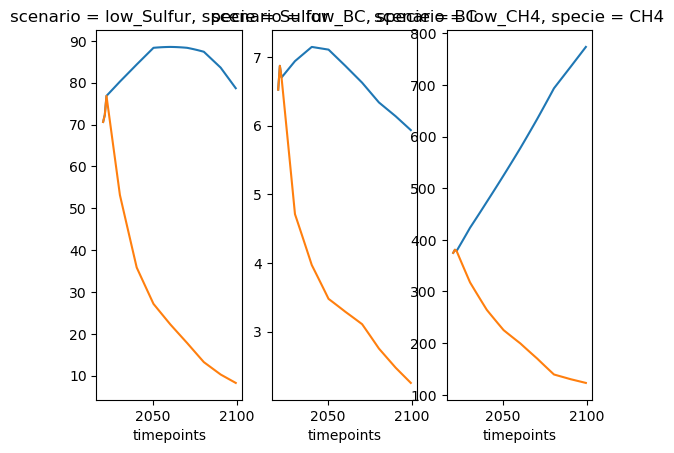

In [52]:
plt.subplot(131)
aerosol_model.emissions.sel(timepoints=slice(2020,2100),specie="Sulfur",scenario="high_Sulfur").mean(dim="config").plot()
aerosol_model.emissions.sel(timepoints=slice(2020,2100),specie="Sulfur",scenario="low_Sulfur").mean(dim="config").plot()
plt.subplot(132)
aerosol_model.emissions.sel(timepoints=slice(2020,2100),specie="BC",scenario="high_BC").mean(dim="config").plot()
aerosol_model.emissions.sel(timepoints=slice(2020,2100),specie="BC",scenario="low_BC").mean(dim="config").plot()
plt.subplot(133)
aerosol_model.emissions.sel(timepoints=slice(2020,2100),specie="CH4",scenario="high_CH4").mean(dim="config").plot()
aerosol_model.emissions.sel(timepoints=slice(2020,2100),specie="CH4",scenario="low_CH4").mean(dim="config").plot()


# Implications of different SLCF scenarios
In the "low" scenario, warming from aerosols is more than cancelled out by cooling from methane reductions.  High methane emissions wipe out all gains and add net warming

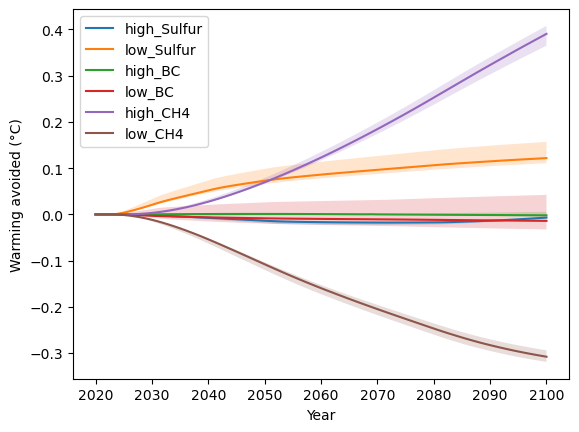

In [53]:
plot_T_diff(aerosol_model,baseline_scenario="constant")


# What we need
## Solutions disaggregated by pollutant
* Megan has these in spreadsheets [example](https://docs.google.com/spreadsheets/d/1szin22ay9ttZbX7LAiW8QEk75_CQPB25xuXXqUSvrI0/edit?gid=782362116#gid=782362116)
* Need to scale by GWP20/100 to get CH4/N20 units

## Temporal adoption trajectories
* All at once
* Linear scaling
* S-curve
* Anything else?
  
## Baseline scenario
* Constant emissions?
* CMIP7 medium?

## Emergency brake classification
* Are emergency brakes defined by time to implement?
* Or time to work (ie reduce warming?)

## Pipeline
* What do we want users to be able to specify?
